## Build Time Series Dataset

In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [53]:
np.random.seed(42)
n_days = 730   # 2 years of daily data

In [54]:
# Simulate daily student attendance data
dates = pd.date_range(start='2022-01-01', periods=n_days, freq='D')

In [55]:
# Build realistic time series:
# trend + weekly seasonality + yearly seasonality + noise
trend      = np.linspace(50, 80, n_days)               # gradual increase
weekly     = 10 * np.sin(2 * np.pi * np.arange(n_days) / 7)
yearly     = 15 * np.sin(2 * np.pi * np.arange(n_days) / 365)
noise      = np.random.normal(0, 3, n_days)

attendance = np.round((trend + weekly + yearly + noise).clip(0, 100), 3)

df = pd.DataFrame({'date': dates, 'attendance': attendance})
df = df.set_index('date')

In [56]:
df.shape

(730, 1)

In [57]:
df.head()

,attendance
date,
2022-01-01,51.490
2022-01-02,57.703
2022-01-03,62.291
2022-01-04,59.806
2022-01-05,46.155


In [58]:
# Create features from the time series
df['day_of_week']  = df.index.dayofweek.astype(float)
df['month']        = df.index.month.astype(float)
df['day_of_year']  = df.index.dayofyear.astype(float)
df['week_of_year'] = df.index.isocalendar().week.astype(float)

# Lag features (past values as features)
df['lag_1']  = df['attendance'].shift(1)   # yesterday
df['lag_7']  = df['attendance'].shift(7)   # last week same day
df['lag_30'] = df['attendance'].shift(30)  # last month

# Rolling statistics
df['rolling_mean_7']  = np.round(df['attendance'].shift(1).rolling(7).mean(), 3)
df['rolling_std_7']   = np.round(df['attendance'].shift(1).rolling(7).std(), 3)
df['rolling_mean_30'] = np.round(df['attendance'].shift(1).rolling(30).mean(), 3)

In [59]:
df.sample(5)

,attendance,day_of_week,month,day_of_year,week_of_year,lag_1,lag_7,lag_30,rolling_mean_7,rolling_std_7,rolling_mean_30
date,,,,,,,,,,,
2022-04-28,55.110,3.0,4.0,118.0,17.0,63.990,53.247,73.865,68.883,10.476,68.679
2023-10-16,68.751,0.0,10.0,289.0,42.0,69.231,63.360,65.222,62.130,5.374,61.348
2022-03-09,65.141,2.0,3.0,68.0,10.0,70.444,59.574,64.314,65.472,10.177,63.634
2022-03-04,54.552,4.0,3.0,63.0,9.0,55.216,59.412,54.789,65.171,7.960,61.535
2023-10-13,59.758,4.0,10.0,286.0,41.0,54.280,49.173,54.579,59.864,6.853,60.416


In [60]:
# Drop rows with NaN (from lags and rolling)
df = df.dropna()

In [61]:
feature_cols = ['day_of_week', 'month', 'day_of_year', 'week_of_year', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30']

In [62]:
X = df[feature_cols].values
y = df['attendance'].values

In [63]:
df.index

DatetimeIndex(['2022-01-31', '2022-02-01', '2022-02-02', '2022-02-03',
               '2022-02-04', '2022-02-05', '2022-02-06', '2022-02-07',
               '2022-02-08', '2022-02-09',
               ...
               '2023-12-22', '2023-12-23', '2023-12-24', '2023-12-25',
               '2023-12-26', '2023-12-27', '2023-12-28', '2023-12-29',
               '2023-12-30', '2023-12-31'],
              dtype='datetime64[us]', name='date', length=700, freq=None)

Dataset shape: (700, 10)
Date range: 2022-01-31 to 2023-12-31


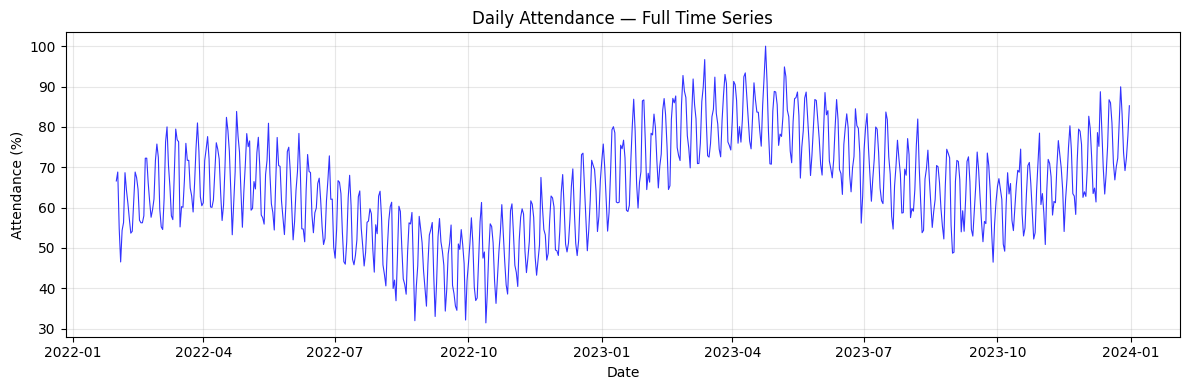

In [65]:
dates_clean = df.index

print(f"Dataset shape: {X.shape}")
print(f"Date range: {dates_clean[0].date()} to {dates_clean[-1].date()}")

# Plot raw time series
plt.figure(figsize=(12, 4))
plt.plot(dates_clean, y, color='blue', linewidth=0.8, alpha=0.8)
plt.title("Daily Attendance — Full Time Series")
plt.xlabel("Date")
plt.ylabel("Attendance (%)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualize All CV Strategies

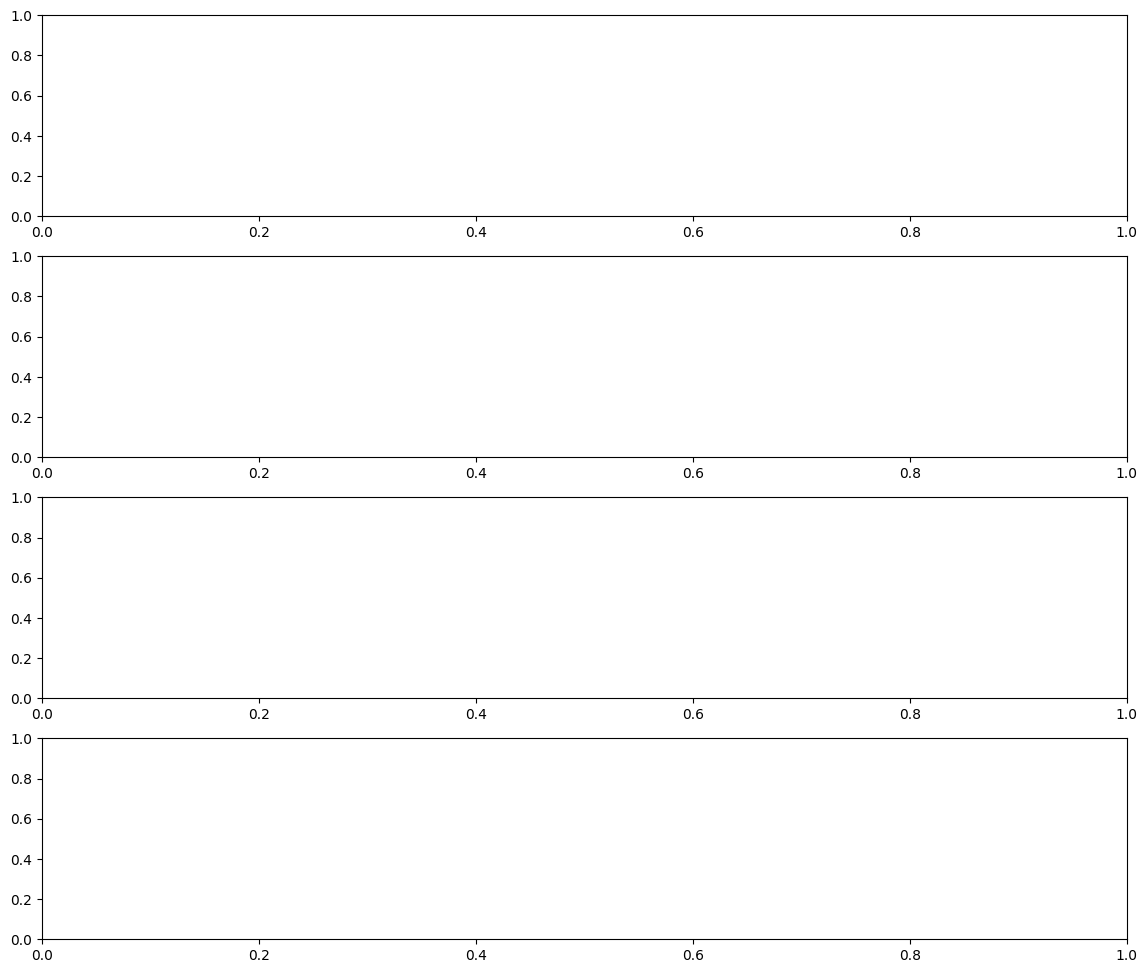

## 1- Expanding Window

[Text(0, 0, 'Fold 1'),
 Text(0, 1, 'Fold 2'),
 Text(0, 2, 'Fold 3'),
 Text(0, 3, 'Fold 4'),
 Text(0, 4, 'Fold 5')]

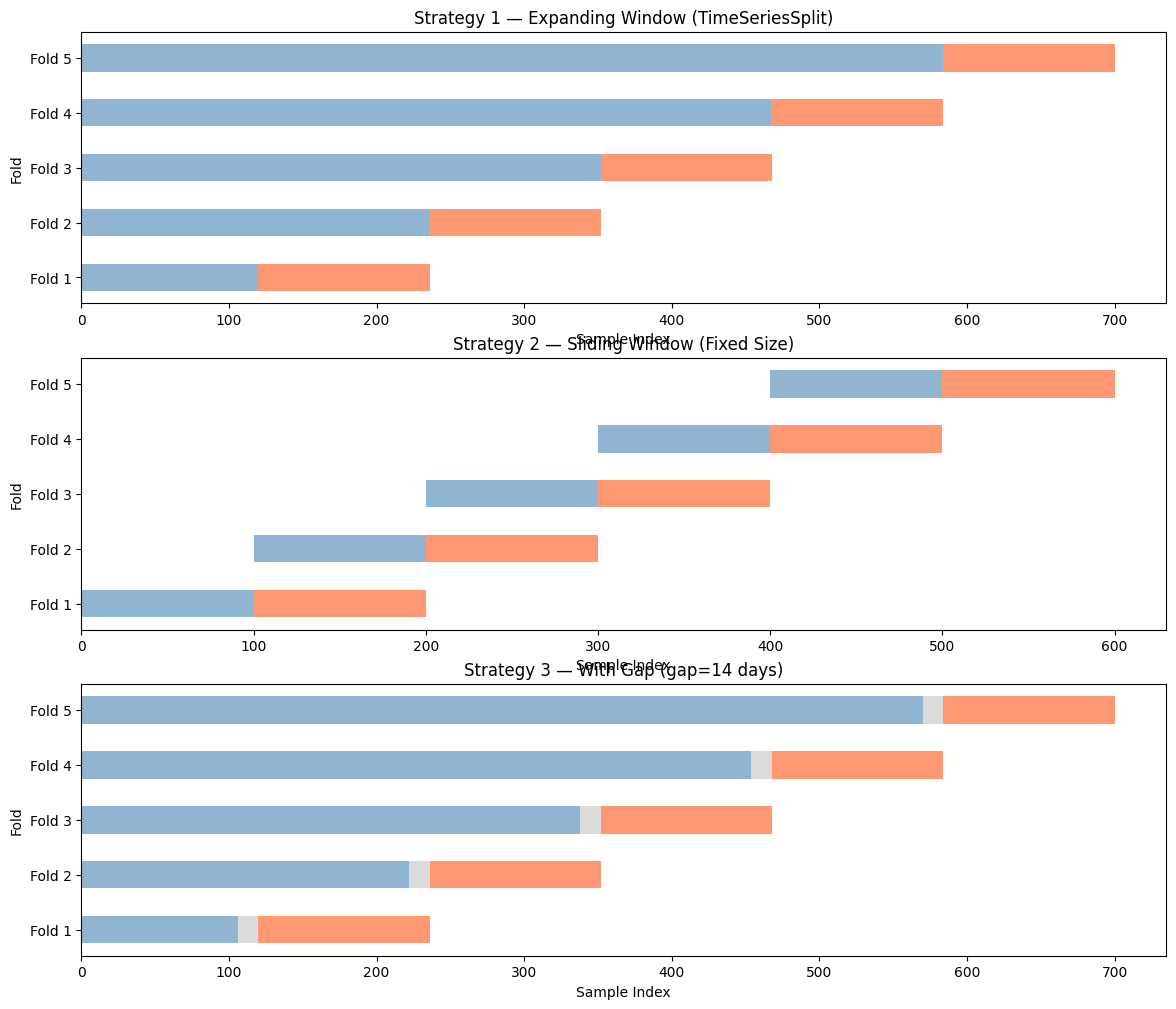

In [71]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

colors_train = 'steelblue'
colors_test  = 'coral'
colors_gap   = 'lightgray'


# Expanding Window
tscv_expand = TimeSeriesSplit(n_splits=5)

ax = axes[0]
for fold, (train_idx, test_idx) in enumerate(tscv_expand.split(X)):
    ax.barh(fold, len(train_idx),
            left=train_idx[0],
            color=colors_train, alpha=0.6, height=0.5)
    ax.barh(fold, len(test_idx),
            left=test_idx[0],
            color=colors_test, alpha=0.8, height=0.5)

ax.set_title("Strategy 1 — Expanding Window (TimeSeriesSplit)",
             fontsize=12)
ax.set_xlabel("Sample Index")
ax.set_ylabel("Fold")
ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])



# Sliding Window
window_size = 100

ax = axes[1]
n_splits    = 5
step        = (len(X) - window_size) // (n_splits + 1)

for fold in range(n_splits):
    start  = fold * step
    end    = start + window_size
    t_end  = end + step

    ax.barh(fold, window_size, left=start,
            color=colors_train, alpha=0.6, height=0.5)
    ax.barh(fold, step, left=end,
            color=colors_test,  alpha=0.8, height=0.5)

ax.set_title("Strategy 2 — Sliding Window (Fixed Size)",
             fontsize=12)
ax.set_xlabel("Sample Index")
ax.set_ylabel("Fold")
ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])



# With Gap
gap_size    = 14   # 2 week gap
tscv_gap    = TimeSeriesSplit(n_splits=5, gap=gap_size)

ax = axes[2]
for fold, (train_idx, test_idx) in enumerate(tscv_gap.split(X)):
    ax.barh(fold, len(train_idx),
            left=train_idx[0],
            color=colors_train, alpha=0.6, height=0.5)
    ax.barh(fold, gap_size,
            left=train_idx[-1]+1,
            color=colors_gap, alpha=0.8, height=0.5,
            label='Gap' if fold==0 else '')
    ax.barh(fold, len(test_idx),
            left=test_idx[0],
            color=colors_test, alpha=0.8, height=0.5)

ax.set_title(f"Strategy 3 — With Gap (gap={gap_size} days)",
             fontsize=12)
ax.set_xlabel("Sample Index")
ax.set_ylabel("Fold")
ax.set_yticks(range(5))
ax.set_yticklabels([f"Fold {i+1}" for i in range(5)])